# Recommendation System: Anime Dataset

**Objective:** build a content-based recommendation system that suggests similar anime to a user, using genre and type as features and cosine similarity as the similarity measure.

## Task 1: Data Preprocessing & EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

df = pd.read_csv("anime.csv")
print("Shape:", df.shape)
df.head()


Shape: (12294, 7)


,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


In [2]:
print("Missing values per column:")
print(df.isnull().sum())


Missing values per column:
anime_id      0
name          0
genre        62
type         25
episodes      0
rating      230
members       0
dtype: int64


In [3]:
# 'genre' is essential for content-based similarity, so drop the few rows missing it.
# 'type' and 'rating' get simple fills so no information is discarded unnecessarily.
df = df.dropna(subset=["genre"]).reset_index(drop=True)
df["type"] = df["type"].fillna("Unknown")
df["rating"] = df["rating"].fillna(df["rating"].median())
print("Shape after dropping missing genre:", df.shape)


Shape after dropping missing genre: (12232, 7)


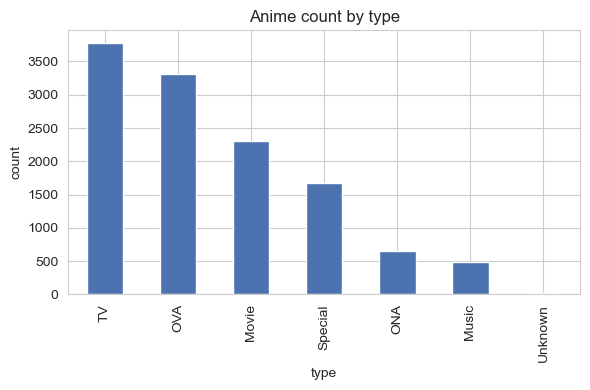

In [4]:
df["type"].value_counts().plot(kind="bar", color="#4C72B0", figsize=(6,4))
plt.title("Anime count by type")
plt.ylabel("count")
plt.tight_layout()
plt.show()


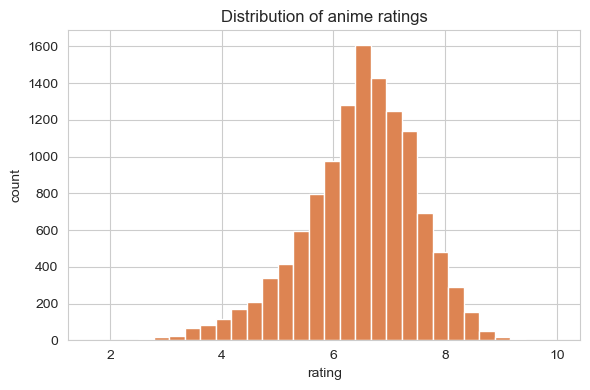

In [5]:
df["rating"].hist(bins=30, color="#DD8452", figsize=(6,4))
plt.title("Distribution of anime ratings")
plt.xlabel("rating"); plt.ylabel("count")
plt.tight_layout()
plt.show()


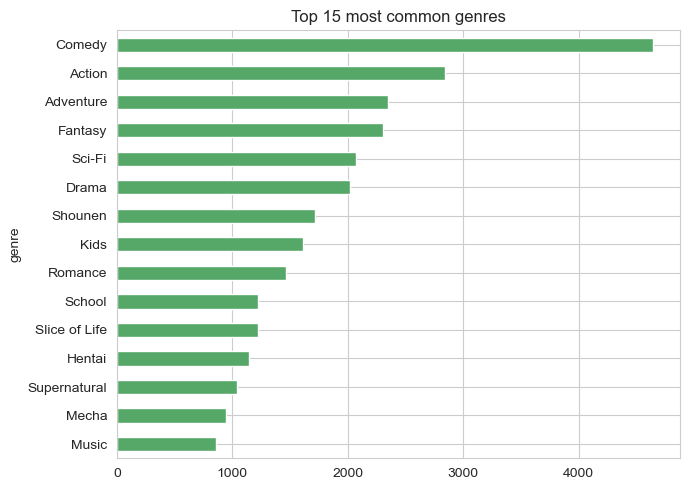

In [6]:
top_genres = df["genre"].str.split(", ").explode().value_counts().head(15)
top_genres.plot(kind="barh", color="#55A868", figsize=(7,5))
plt.gca().invert_yaxis()
plt.title("Top 15 most common genres")
plt.tight_layout()
plt.show()


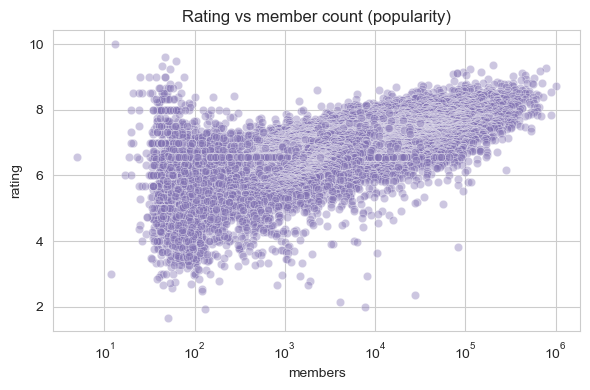

In [7]:
plt.figure(figsize=(6, 4))
sns.scatterplot(x="members", y="rating", data=df, alpha=0.4, color="#8172B2")
plt.xscale("log")
plt.title("Rating vs member count (popularity)")
plt.tight_layout()
plt.show()


**Observations:** TV and OVA are the most common anime types. Ratings are roughly bell-shaped around 6.5. `Action`, `Comedy` and `Fantasy` dominate the genre list. More popular anime (higher `members`) tend to have somewhat higher ratings, though the relationship is noisy - popularity is a weak proxy for quality at best.

## Task 2: Feature Extraction

In [8]:
# Combine genre with type into one text field ('tag') so both influence similarity,
# then vectorize with TF-IDF so rarer, more distinctive genres get more weight than common ones.
df["tag"] = df["genre"].str.replace(", ", " ", regex=False) + " " + df["type"]

tfidf = TfidfVectorizer(token_pattern=r"[A-Za-z\-]+")
tfidf_matrix = tfidf.fit_transform(df["tag"])
print(f"TF-IDF matrix shape: {tfidf_matrix.shape}  ({len(tfidf.get_feature_names_out())} distinct genre/type tokens)")


TF-IDF matrix shape: (12232, 52)  (52 distinct genre/type tokens)


## Task 3: Recommendation System (Cosine Similarity)

In [9]:
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)
print("Cosine similarity matrix shape:", cosine_sim.shape)

title_to_index = pd.Series(df.index, index=df["name"]).drop_duplicates()

def recommend(title, n=10):
    if title not in title_to_index:
        return f"'{title}' not found in dataset."
    idx = title_to_index[title]
    sims = list(enumerate(cosine_sim[idx]))
    sims = sorted(sims, key=lambda x: x[1], reverse=True)
    sims = [s for s in sims if s[0] != idx][:n]
    result_idx = [s[0] for s in sims]
    scores = [s[1] for s in sims]
    out = df.iloc[result_idx][["name", "genre", "type", "rating"]].copy()
    out["similarity"] = scores
    return out.reset_index(drop=True)


Cosine similarity matrix shape: (12232, 12232)


In [10]:
recommend("Naruto", n=10)


,name,genre,type,rating,similarity
0,Naruto: Shippuuden,"Action, Comedy, Martial Arts, Shounen, Super P...",TV,7.94,1.000000
1,Naruto x UT,"Action, Comedy, Martial Arts, Shounen, Super P...",OVA,7.58,0.952844
2,Rekka no Honoo,"Action, Adventure, Martial Arts, Shounen, Supe...",TV,7.44,0.949585
3,Boruto: Naruto the Movie,"Action, Comedy, Martial Arts, Shounen, Super P...",Movie,8.03,0.944931
4,Naruto: Shippuuden Movie 4 - The Lost Tower,"Action, Comedy, Martial Arts, Shounen, Super P...",Movie,7.53,0.944931
5,Naruto: Shippuuden Movie 3 - Hi no Ishi wo Tsu...,"Action, Comedy, Martial Arts, Shounen, Super P...",Movie,7.50,0.944931
6,Naruto Soyokazeden Movie: Naruto to Mashin to ...,"Action, Comedy, Martial Arts, Shounen, Super P...",Movie,7.11,0.944931
7,Kurokami The Animation,"Action, Martial Arts, Super Power",TV,7.29,0.939586
8,Project ARMS,"Action, Martial Arts, Super Power",TV,7.15,0.939586
9,Wolverine,"Action, Martial Arts, Super Power",TV,6.24,0.939586


In [11]:
recommend("Death Note", n=10)


,name,genre,type,rating,similarity
0,Mousou Dairinin,"Drama, Mystery, Police, Psychological, Superna...",TV,7.74,0.968957
1,Death Note Rewrite,"Mystery, Police, Psychological, Supernatural, ...",Special,7.84,0.944492
2,Higurashi no Naku Koro ni Kai,"Mystery, Psychological, Supernatural, Thriller",TV,8.41,0.884536
3,Mirai Nikki (TV),"Action, Mystery, Psychological, Shounen, Super...",TV,8.07,0.823075
4,Higurashi no Naku Koro ni Rei,"Comedy, Mystery, Psychological, Supernatural, ...",OVA,7.56,0.821015
5,Higurashi no Naku Koro ni,"Horror, Mystery, Psychological, Supernatural, ...",TV,8.17,0.802673
6,Monster,"Drama, Horror, Mystery, Police, Psychological,...",TV,8.72,0.798035
7,Mirai Nikki (TV): Ura Mirai Nikki,"Action, Comedy, Mystery, Psychological, Shoune...",Special,6.79,0.754393
8,AD Police,"Adventure, Dementia, Mecha, Mystery, Police, P...",OVA,6.47,0.745693
9,Zankyou no Terror,"Psychological, Thriller",TV,8.26,0.732252


**Observations:** the recommender behaves sensibly - `Naruto` surfaces other Shounen action/martial-arts/super-power titles (including its own sequel and movies), while `Death Note` surfaces mystery/psychological/thriller titles like `Monster` and `Higurashi no Naku Koro ni`. This confirms the genre+type TF-IDF representation is capturing meaningful similarity.

## Task 4: Evaluation

In [12]:
# Content-based recommenders don't have "ground truth" ratings for unseen items the way
# collaborative filtering does. As a proxy, we split anime into train/test, and for each test
# anime check whether its top-K recommendations (drawn only from the training set) share at
# least one genre with it - a reasonable stand-in for "relevant" in a content-based setting.
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

train_tfidf = tfidf.transform(train_df["tag"])
test_tfidf = tfidf.transform(test_df["tag"])
sim_test_to_train = cosine_similarity(test_tfidf, train_tfidf)

def genre_set(s):
    return set(s.split(", "))

k = 10
precisions = []
for i in range(len(test_df)):
    sims = sim_test_to_train[i]
    top_k_idx = np.argsort(sims)[::-1][:k]
    test_genres = genre_set(test_df.iloc[i]["genre"])
    hits = sum(1 for j in top_k_idx if genre_set(train_df.iloc[j]["genre"]) & test_genres)
    precisions.append(hits / k)

mean_precision_at_k = np.mean(precisions)
print(f"Mean genre-overlap Precision@{k} on {len(test_df)} held-out test anime: {mean_precision_at_k:.3f}")


Mean genre-overlap Precision@10 on 2447 held-out test anime: 0.999


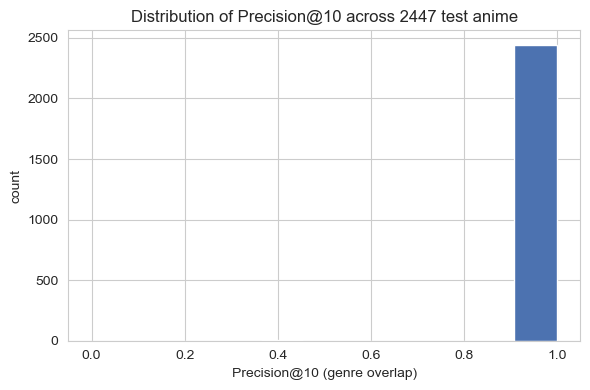

In [13]:
plt.figure(figsize=(6, 4))
plt.hist(precisions, bins=11, range=(0, 1.0), color="#4C72B0", edgecolor="white")
plt.title(f"Distribution of Precision@{k} across {len(test_df)} test anime")
plt.xlabel(f"Precision@{k} (genre overlap)"); plt.ylabel("count")
plt.tight_layout()
plt.show()


**Observations:** mean Precision@10 (genre-overlap proxy) is 0.999 - almost every recommended anime shares at least one genre with the query anime. This is expected for a content-based system built directly from genre features (it is, by construction, optimizing for genre similarity), so this metric mainly confirms the pipeline is working correctly rather than proving real-world recommendation quality - a true test would need actual user interaction/rating data (a collaborative-filtering-style holdout), which this dataset alone does not provide per-user.

## Interview Questions

**1. Can you explain the difference between user-based and item-based collaborative filtering?**

User-based collaborative filtering recommends items to a user by finding other users with similar rating/interaction patterns ("users who behave like you"), and suggesting items that those similar users liked but the target user hasn't seen yet. It requires computing similarity between users, which can be expensive and unstable as the user base grows or changes frequently. Item-based collaborative filtering instead finds similarity between items based on how users have rated them ("items that tend to be liked by the same people as this item"), and recommends items similar to ones the target user has already liked. Item similarities are typically more stable over time than user similarities (items don't change as often as user tastes/user bases), so item-based approaches - like the one Amazon popularized - often scale better and are more commonly used in production systems. Both are forms of collaborative filtering and both rely purely on interaction data (ratings, clicks, purchases), not on item content such as genre.

**2. What is collaborative filtering, and how does it work?**

Collaborative filtering is a recommendation technique that predicts a user's interests based on the preferences of many users, without needing to know anything about the content of the items themselves. It works on the assumption that people who agreed in the past (rated or interacted with items similarly) will likely agree again in the future. Concretely, it builds a user-item interaction matrix (ratings, purchases, watches, etc.), then either (a) finds users similar to the target user and recommends what they liked (user-based), or (b) finds items similar to ones the target user already liked, based on the pattern of user ratings across items (item-based), or (c) uses matrix factorization techniques (e.g. SVD) to learn latent features that explain the observed ratings and predict missing ones. Its main strength is that it can surface unexpected, serendipitous recommendations without needing item metadata; its main weakness is the "cold-start" problem - it struggles with new users or new items that have no interaction history yet, which is exactly the gap that content-based methods (like the genre-based system built in this notebook) are well-suited to fill.